In [4]:
# ============================================================
# BLOQUE 1 — CARGA ROBUSTA DEL EXPERIMENTO
# ============================================================

import os
import sys
import glob
import yaml
import joblib
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================
# ROOT ROBUSTO UNIVERSAL
# ============================================================

from pathlib import Path

current = Path.cwd()

project_root = None

for parent in [current] + list(current.parents):

    if (parent / "configs").exists() and (parent / "scripts").exists():
        project_root = parent
        break

if project_root is None:
    raise RuntimeError(
        "❌ No se pudo encontrar la raíz del proyecto."
    )

project_root = str(project_root)

if project_root not in sys.path:
    sys.path.append(project_root)

print("=" * 60)
print("PROJECT ROOT")
print("=" * 60)
print(project_root)

print("\nCURRENT WORKDIR:")
print(Path.cwd())
# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def clean_path(yaml_path, root):
    """
    Limpia ../../ y reconstruye rutas absolutas
    robustas desde notebooks.
    """
    limpio = (
        yaml_path
        .replace('../../', '')
        .replace('../', '')
    )

    return os.path.normpath(
        os.path.join(root, limpio)
    )

# ------------------------------------------------------------
# YAML DEL EXPERIMENTO
# ------------------------------------------------------------

yaml_path = os.path.join(
    project_root,
    'configs',
    'experiments',
    'depured_methology_experiments',
    'feat_task_k4_diag_pca90_fullfeatures_v2.yaml'
)

print("\nYAML PATH:")
print(yaml_path)

if not os.path.exists(yaml_path):
    raise FileNotFoundError(
        f"\n❌ No existe el YAML:\n{yaml_path}"
    )

with open(yaml_path, 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

exp_name = cfg['experiment']['name']

n_states = cfg['pipeline']['hmm']['k_states']

print("\nExperiment:")
print(exp_name)

print(f"K States: {n_states}")

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

out_dir_base = clean_path(
    cfg['paths']['output_dir'],
    project_root
)

exp_dir = os.path.join(
    out_dir_base,
    exp_name
)

features_dir = clean_path(
    cfg['paths']['features_dir'],
    project_root
)

print("\n" + "=" * 60)
print("PATHS")
print("=" * 60)

print(f"Experiment Dir:\n{exp_dir}")
print(f"\nFeatures Dir:\n{features_dir}")

# ------------------------------------------------------------
# LOAD VITERBI
# ------------------------------------------------------------

viterbi_path = os.path.join(
    exp_dir,
    f'viterbi_paths_k{n_states}.npy'
)

print("\nViterbi Path:")
print(viterbi_path)

if not os.path.exists(viterbi_path):
    raise FileNotFoundError(
        f"\n❌ No existe:\n{viterbi_path}"
    )

viterbi_paths = np.load(viterbi_path)

# ------------------------------------------------------------
# LOAD FEATURES
# ------------------------------------------------------------

feature_files = sorted(
    glob.glob(
        os.path.join(features_dir, '*_features.npy')
    )
)

if len(feature_files) == 0:
    raise ValueError(
        f"\n❌ No se encontraron features en:\n{features_dir}"
    )

print(f"\nFeatures encontradas: {len(feature_files)}")

X_original = np.vstack([
    np.load(f)
    for f in feature_files
])

# ------------------------------------------------------------
# LOAD SCALER
# ------------------------------------------------------------

scaler_path = os.path.join(
    exp_dir,
    'scaler.pkl'
)

print("\nScaler Path:")
print(scaler_path)

if not os.path.exists(scaler_path):
    raise FileNotFoundError(
        f"\n❌ No existe scaler:\n{scaler_path}"
    )

scaler = joblib.load(scaler_path)

X_scaled = scaler.transform(X_original)

# ------------------------------------------------------------
# CHECKS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DEBUG DATA")
print("=" * 60)

print(f"Experiment: {exp_name}")

print(f"\nX_original shape: {X_original.shape}")
print(f"X_scaled shape:   {X_scaled.shape}")

print(f"Viterbi shape:    {viterbi_paths.shape}")

print("\nFeature dimensions:")
print(X_original.shape[1])

assert X_scaled.shape[0] == len(viterbi_paths), (
    "\n❌ Mismatch entre Viterbi y Features"
)

print("\n✅ Carga completada correctamente.")

PROJECT ROOT
c:\Proyectos\eeg_hmm_project

CURRENT WORKDIR:
c:\Proyectos\eeg_hmm_project\notebooks\reports\depured_methology_experiments

YAML PATH:
c:\Proyectos\eeg_hmm_project\configs\experiments\depured_methology_experiments\feat_task_k4_diag_pca90_fullfeatures_v2.yaml

Experiment:
feat_task_k4_diag_pca90_fullfeatures_v2
K States: 4

PATHS
Experiment Dir:
c:\Proyectos\eeg_hmm_project\outputs\processed\experiments\feature_hmm\task\feat_task_k4_diag_pca90_fullfeatures_v2

Features Dir:
c:\Proyectos\eeg_hmm_project\data\interim\features\task_fullfeatures_v2

Viterbi Path:
c:\Proyectos\eeg_hmm_project\outputs\processed\experiments\feature_hmm\task\feat_task_k4_diag_pca90_fullfeatures_v2\viterbi_paths_k4.npy

Features encontradas: 118

Scaler Path:
c:\Proyectos\eeg_hmm_project\outputs\processed\experiments\feature_hmm\task\feat_task_k4_diag_pca90_fullfeatures_v2\scaler.pkl

DEBUG DATA
Experiment: feat_task_k4_diag_pca90_fullfeatures_v2

X_original shape: (25949, 114)
X_scaled shape:   (2

In [7]:
# ============================================================
# EVOKED STATE DYNAMICS (GO vs NO-GO)
# VERSIÓN CORREGIDA — ALINEACIÓN TEMPORAL REAL
# ============================================================

import os
import glob
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

# ============================================================
# CONFIG
# ============================================================

CONFIG_PATH = "../../configs/experiments/feat_task_k3_diag_pca90_hjorthonly_temporalqc.yaml"

# ------------------------------------------------------------
# PARÁMETROS TEMPORALES REALES
# ------------------------------------------------------------

EPOCH_START_MS = -500
WINDOW_SIZE_MS = 200
STEP_SIZE_MS = 100

LISTA_ADULTOS = [
    'AAELSC', 'AAGFSC', 'EDGSSIN', 'FIJRBSIN', 'GSASC', 'IJALSC',
    'JAGSSC', 'LHACSIN', 'MAEGLSC', 'MAHLSC', 'MFGSIN', 'MGOKSC',
    'RAMPSIN', 'SDBGSIN', 'VMRSIN', 'AVLLSC', 'BMPSC', 'CGMSIN',
    'CJGSIN', 'CPGSC', 'CPMHSIN', 'GGMSIN', 'IABWSC', 'JAUSIN',
    'JGCSC', 'MGVGSC', 'RKACSC', 'SEOOSIN', 'TTOSC', 'VBPSIN'
]

# ============================================================
# LOAD EXPERIMENT
# ============================================================

with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

exp_name = cfg['experiment']['name']
k = cfg['pipeline']['hmm']['k_states']

exp_dir = os.path.join(
    "../../outputs/processed/experiments/feature_hmm/task/",
    exp_name
)

features_dir = "../../data/interim/features/task/"

print("=" * 60)
print(f"Cargando experimento: {exp_name}")
print("=" * 60)

viterbi = np.load(
    os.path.join(exp_dir, f'viterbi_paths_k{k}.npy')
)

length_files = sorted(
    glob.glob(os.path.join(features_dir, '*_lengths.npy'))
)

print(f"Estados HMM: {k}")
print(f"Sujetos cargados: {len(length_files)}")

# ============================================================
# HELPERS
# ============================================================

def parse_subject_info(filename):

    clean_name = filename.upper()

    clean_name = clean_name.replace('_SIN_CONTEXTO', '')
    clean_name = clean_name.replace('_EPO', '')
    clean_name = clean_name.replace('_LENGTHS.NPY', '')
    clean_name = clean_name.replace('.NPY', '')

    if clean_name.endswith("NOGO"):
        condicion = "NOGO"
        subject_id_real = clean_name[:-4]

    elif clean_name.endswith("NG"):
        condicion = "NOGO"
        subject_id_real = clean_name[:-2]

    elif clean_name.endswith("GO"):
        condicion = "GO"
        subject_id_real = clean_name[:-2]

    else:
        condicion = "GO"
        subject_id_real = clean_name

    grupo = "ADOLESCENTE"

    for adulto in LISTA_ADULTOS:
        if subject_id_real.startswith(adulto):
            grupo = "ADULTO"
            break

    return subject_id_real, grupo, condicion


def calcular_probabilidades(matriz, n_states):

    if len(matriz) == 0:
        return np.zeros((n_states, WINDOWS_PER_EPOCH))

    probs = np.zeros((n_states, matriz.shape[1]))

    for s in range(n_states):
        probs[s] = np.mean(matriz == s, axis=0)

    return probs

# ============================================================
# RECONSTRUCCIÓN DE SECUENCIAS
# ============================================================

print("\nReconstruyendo épocas...")

secuencias_crudas = {
    "GO": [],
    "NOGO": [],
    "ADULTO_GO": [],
    "ADULTO_NOGO": [],
    "ADOLESCENTE_GO": [],
    "ADOLESCENTE_NOGO": []
}

start_idx = 0
todas_las_longitudes = []

for f_path in length_files:

    filename = os.path.basename(f_path)

    subject_id_real, grupo, condicion = parse_subject_info(filename)

    lengths = np.load(f_path)

    for ep_len in lengths:

        ep_path = viterbi[start_idx:start_idx + ep_len]

        start_idx += ep_len

        todas_las_longitudes.append(ep_len)

        secuencias_crudas[condicion].append(ep_path)

        secuencias_crudas[f"{grupo}_{condicion}"].append(ep_path)

# ============================================================
# DETECCIÓN AUTOMÁTICA DE TAMAÑO DE ÉPOCA
# ============================================================

WINDOWS_PER_EPOCH = Counter(
    todas_las_longitudes
).most_common(1)[0][0]

print(f"\nVentanas por época detectadas: {WINDOWS_PER_EPOCH}")

# ============================================================
# FILTRAR ÉPOCAS VÁLIDAS
# ============================================================

matrices = {}

for key, lista_epocas in secuencias_crudas.items():

    epocas_validas = [
        ep for ep in lista_epocas
        if len(ep) == WINDOWS_PER_EPOCH
    ]

    matrices[key] = np.array(epocas_validas)

    print(f"{key}: {len(epocas_validas)} épocas")

# ============================================================
# EJE TEMPORAL CORRECTO
# ============================================================

time_axis = (
    np.arange(WINDOWS_PER_EPOCH) * STEP_SIZE_MS
    + EPOCH_START_MS
    + (WINDOW_SIZE_MS / 2)
)

print("\n" + "=" * 60)
print("TIME AXIS")
print("=" * 60)

print(f"Inicio real: {time_axis[0]} ms")
print(f"Final real: {time_axis[-1]} ms")

# ============================================================
# PROBABILIDADES EVOCADAS
# ============================================================

probs = {
    key: calcular_probabilidades(value, k)
    for key, value in matrices.items()
}

# ============================================================
# PLOT 1 — GO vs NOGO
# ============================================================

sns.set_theme(
    style="whitegrid",
    context="talk"
)

colors = sns.color_palette("husl", k)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    sharey=True,
    sharex=True
)

paneles = [
    ("GO", "Condición GO"),
    ("NOGO", "Condición NO-GO")
]

for ax, (key, title) in zip(axes, paneles):

    matriz = probs[key]

    for s in range(k):

        ax.plot(
            time_axis,
            matriz[s],
            lw=3,
            label=f"Estado {s}",
            color=colors[s]
        )

    ax.set_title(
        title,
        fontsize=16,
        fontweight='bold'
    )

    ax.set_xlabel("Tiempo post-estímulo (ms)")
    ax.set_ylabel("Probabilidad")

    # ESTÍMULO REAL
    ax.axvline(
        x=0,
        linestyle='--',
        alpha=0.8,
        color='black',
        label='Estímulo'
    )

    ax.set_xlim(
        time_axis.min(),
        time_axis.max()
    )

axes[1].legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.suptitle(
    f"Dinámica Evocada de Estados HMM\n{exp_name}",
    fontsize=20,
    y=1.03
)

plt.tight_layout()
plt.show()

# ============================================================
# PLOT 2 — MATRIZ 2x2 DESARROLLO
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 10),
    sharex=True,
    sharey=True
)

config_panels = [
    (0, 0, "ADOLESCENTE_GO", "Adolescentes GO"),
    (0, 1, "ADOLESCENTE_NOGO", "Adolescentes NO-GO"),
    (1, 0, "ADULTO_GO", "Adultos GO"),
    (1, 1, "ADULTO_NOGO", "Adultos NO-GO")
]

for row, col, key, title in config_panels:

    ax = axes[row, col]

    matriz = probs[key]

    for s in range(k):

        ax.plot(
            time_axis,
            matriz[s],
            lw=2.5,
            label=f"Estado {s}",
            color=colors[s]
        )

    ax.set_title(
        title,
        fontsize=14,
        fontweight='bold'
    )

    ax.axvline(
        x=0,
        linestyle='--',
        alpha=0.8,
        color='black'
    )

    if row == 1:
        ax.set_xlabel("Tiempo post-estímulo (ms)")

    if col == 0:
        ax.set_ylabel("Probabilidad")

    ax.set_xlim(
        time_axis.min(),
        time_axis.max()
    )

axes[0,1].legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.suptitle(
    f"Dinámica Evocada por Edad y Condición\n{exp_name}",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

# ============================================================
# MÉTRICAS TEMPORALES RESUMEN
# ============================================================

print("\n" + "=" * 60)
print("PEAK EVOKED PROBABILITIES")
print("=" * 60)

summary = []

for group_name, matrix in probs.items():

    if matrix.shape[1] == 0:
        continue

    for s in range(k):

        peak_idx = np.argmax(matrix[s])

        peak_time = time_axis[peak_idx]

        peak_prob = matrix[s, peak_idx]

        summary.append({
            'Group': group_name,
            'State': s,
            'Peak Time (ms)': peak_time,
            'Peak Probability': peak_prob
        })

df_summary = pd.DataFrame(summary)

display(df_summary)

FileNotFoundError: [Errno 2] No such file or directory: '../../configs/experiments/feat_task_k3_diag_pca90_hjorthonly_temporalqc.yaml'

In [4]:
# ============================================================
# BLOQUE 2 — DISTRIBUCIÓN GLOBAL DE ESTADOS
# ============================================================

total_windows = len(viterbi_paths)

print("=" * 60)
print(f"Distribución Global de Hidden States (K={n_states})")
print("=" * 60)

print(f"Total de ventanas: {total_windows:,}\n")

for s in range(n_states):

    n = np.sum(viterbi_paths == s)

    occupancy = (n / total_windows) * 100

    print(
        f"State {s}: "
        f"{occupancy:.2f}% "
        f"(n={n:,})"
    )

Distribución Global de Hidden States (K=3)
Total de ventanas: 25,949

State 0: 40.92% (n=10,618)
State 1: 35.16% (n=9,123)
State 2: 23.92% (n=6,208)


In [7]:
# ============================================================
# BLOQUE 3 — CÁLCULO CORRECTO DE STATE PROFILES
# ============================================================

state_profiles = np.zeros(
    (n_states, X_scaled.shape[1])
)

for s in range(n_states):

    idx = (viterbi_paths == s)

    state_profiles[s] = np.mean(
        X_scaled[idx],
        axis=0
    )

print("=" * 60)
print("DEBUG STATE PROFILES")
print("=" * 60)

print(f"Shape: {state_profiles.shape}")

print("\nRango:")
print(f"Min:  {state_profiles.min():.4f}")
print(f"Max:  {state_profiles.max():.4f}")
print(f"Mean: {state_profiles.mean():.4f}")
print(f"STD:  {state_profiles.std():.4f}")

DEBUG STATE PROFILES
Shape: (3, 38)

Rango:
Min:  -0.7094
Max:  0.5658
Mean: -0.0141
STD:  0.3275


COSINE SIMILARITY MATRIX
[[ 1.     -0.4949 -0.2812]
 [-0.4949  1.     -0.6947]
 [-0.2812 -0.6947  1.    ]]


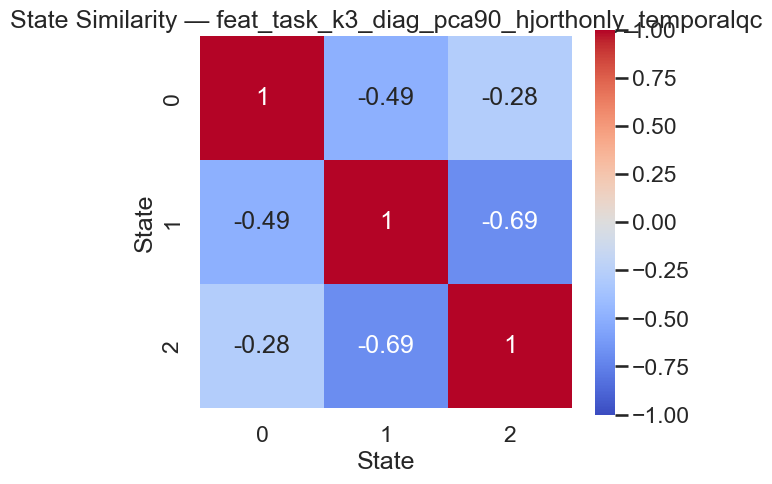

In [8]:
# ============================================================
# BLOQUE 4 — MATRIZ DE SIMILITUD ENTRE ESTADOS
# ============================================================

sim_matrix = cosine_similarity(state_profiles)

print("=" * 60)
print("COSINE SIMILARITY MATRIX")
print("=" * 60)

print(
    np.round(sim_matrix, 4)
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    sim_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True
)

plt.title(
    f"State Similarity — {exp_name}"
)

plt.xlabel("State")
plt.ylabel("State")

plt.show()

In [9]:
# ============================================================
# BLOQUE 5 — TABLA DE SEPARABILIDAD
# ============================================================

rows = []

for s in range(n_states):

    similarities = sim_matrix[s].copy()

    similarities[s] = -999

    best_match = np.argmax(similarities)

    rows.append({
        'state': s,
        'most_similar_state': best_match,
        'similarity': similarities[best_match]
    })

df_sep = pd.DataFrame(rows)

print(df_sep)

upper_triangle = sim_matrix[
    np.triu_indices(n_states, k=1)
]

print("\nMean inter-state similarity:")
print(np.mean(upper_triangle))

   state  most_similar_state  similarity
0      0                   2   -0.281157
1      1                   0   -0.494915
2      2                   0   -0.281157

Mean inter-state similarity:
-0.49027104374190794


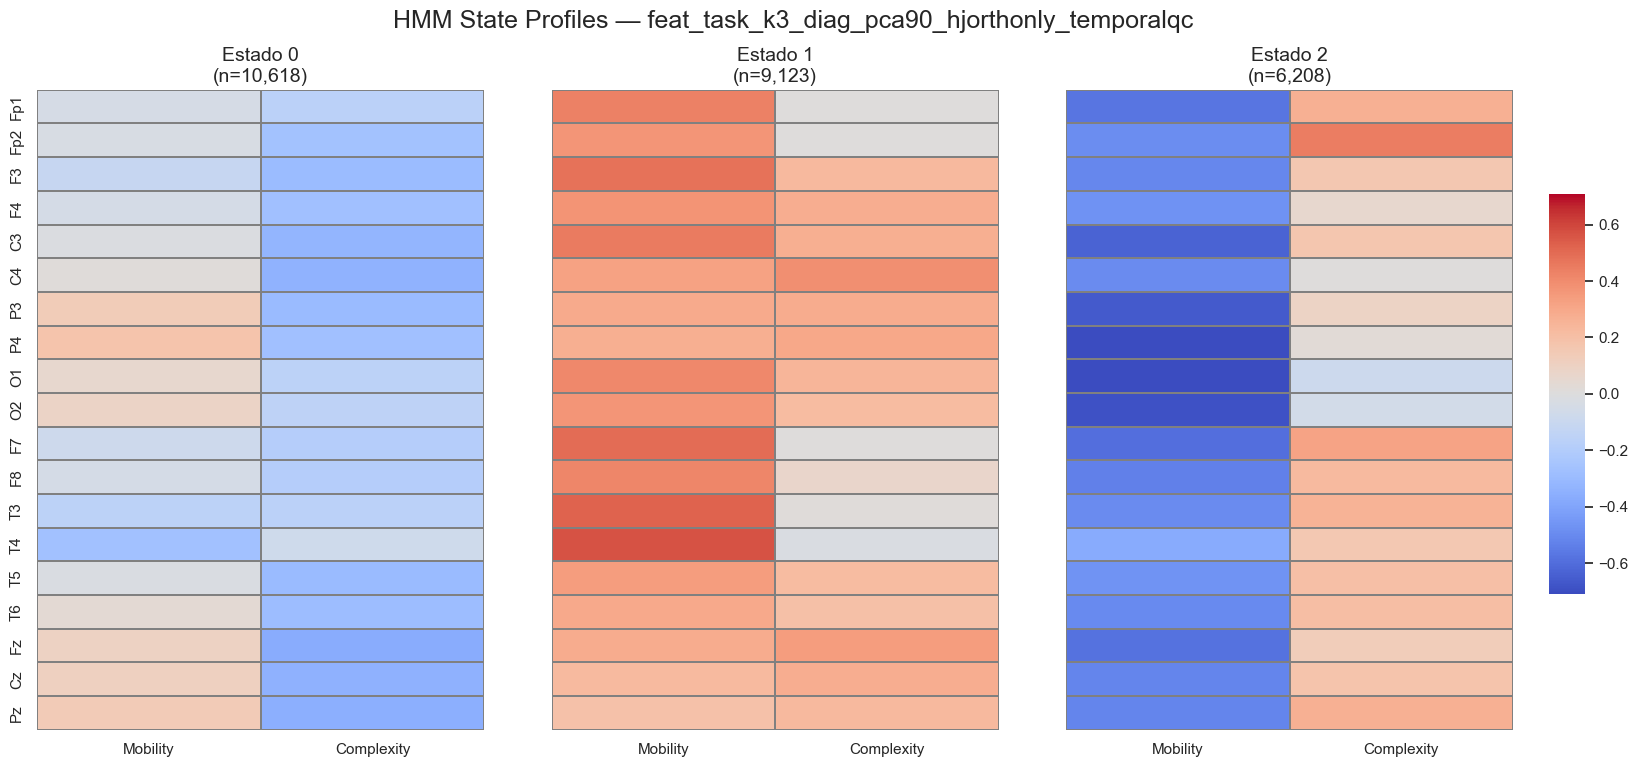

In [10]:
# ============================================================
# BLOQUE 6 — TOPOGRAFÍAS / HEATMAPS
# ============================================================

sns.set_theme(style="white")

# ------------------------------------------------------------
# FEATURES ACTIVAS
# ------------------------------------------------------------

metrics = [
    'Mobility',
    'Complexity'
]

# ------------------------------------------------------------
# CANALES
# ------------------------------------------------------------

ch_names = [
    'Fp1','Fp2','F3','F4','C3','C4','P3','P4',
    'O1','O2','F7','F8','T3','T4','T5','T6',
    'Fz','Cz','Pz'
]

n_channels = len(ch_names)

n_metrics = len(metrics)

# ------------------------------------------------------------
# RESHAPE
# ------------------------------------------------------------

state_profiles_3d = np.zeros(
    (n_states, n_channels, n_metrics)
)

for m_idx in range(n_metrics):

    start_col = m_idx * n_channels

    end_col = (m_idx + 1) * n_channels

    state_profiles_3d[:, :, m_idx] = (
        state_profiles[:, start_col:end_col]
    )

# ------------------------------------------------------------
# VISUALIZACIÓN
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    n_states,
    figsize=(6 * n_states, 8),
    sharey=True
)

if n_states == 1:
    axes = [axes]

global_absmax = np.max(
    np.abs(state_profiles_3d)
)

cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])

for s in range(n_states):

    ax = axes[s]

    sns.heatmap(
        state_profiles_3d[s],
        cmap='coolwarm',
        center=0,
        vmin=-global_absmax,
        vmax=global_absmax,
        xticklabels=metrics,
        yticklabels=ch_names,
        linewidths=0.3,
        linecolor='gray',
        ax=ax,
        cbar=(s == 0),
        cbar_ax=None if s > 0 else cbar_ax
    )

    n_windows = np.sum(viterbi_paths == s)

    ax.set_title(
        f"Estado {s}\n(n={n_windows:,})",
        fontsize=14
    )

plt.suptitle(
    f"HMM State Profiles — {exp_name}",
    fontsize=18,
    y=0.98
)

plt.subplots_adjust(
    left=0.08,
    right=0.9,
    top=0.88,
    bottom=0.08,
    wspace=0.15
)

plt.show()

In [11]:
# ============================================================
# BLOQUE 7 — DWELL TIME
# ============================================================

WINDOW_STEP_MS = 100

def get_mean_dwell_time(path, state, step_ms):

    is_s = (path == state)

    if not np.any(is_s):
        return 0.0

    diffs = np.diff(
        np.concatenate(([0], is_s.view(np.int8), [0]))
    )

    starts = np.where(diffs == 1)[0]

    ends = np.where(diffs == -1)[0]

    return np.mean(
        ends - starts
    ) * step_ms

print("=" * 60)
print("DWELL TIMES")
print("=" * 60)

for s in range(n_states):

    dwell = get_mean_dwell_time(
        viterbi_paths,
        s,
        WINDOW_STEP_MS
    )

    print(
        f"State {s}: "
        f"{dwell:.2f} ms"
    )

DWELL TIMES
State 0: 883.36 ms
State 1: 1070.77 ms
State 2: 578.56 ms


In [12]:
# ============================================================
# CARGAR EL HMM CORRECTO + MATRIZ DE TRANSICIÓN
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# CARGAR MODELO HMM
# ------------------------------------------------------------

model_path = os.path.join(
    exp_dir,
    f'hmm_model_k{n_states}.pkl'
)

print(f"Cargando modelo desde:\n{model_path}")

model = joblib.load(model_path)

# ------------------------------------------------------------
# MATRIZ DE TRANSICIÓN
# ------------------------------------------------------------

transmat = model.transmat_

print("\n" + "=" * 60)
print("TRANSITION MATRIX")
print("=" * 60)

df_transmat = pd.DataFrame(
    np.round(transmat, 3),
    index=[f"From S{i}" for i in range(n_states)],
    columns=[f"To S{i}" for i in range(n_states)]
)

print(df_transmat)

# ------------------------------------------------------------
# MÉTRICAS DE PERSISTENCIA
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STATE PERSISTENCE")
print("=" * 60)

for s in range(n_states):

    occupancy = np.mean(viterbi_paths == s)

    n_windows = np.sum(viterbi_paths == s)

    self_transition = transmat[s, s]

    print(
        f"""
State {s}
---------
Fractional Occupancy : {occupancy:.4f} ({occupancy*100:.2f}%)
Total Windows        : {n_windows:,}
Self-transition      : {self_transition:.4f}
"""
    )

# ------------------------------------------------------------
# ESTADO MÁS PERSISTENTE
# ------------------------------------------------------------

diag_probs = np.diag(transmat)

most_persistent = np.argmax(diag_probs)

print("=" * 60)
print(f"Most persistent state: State {most_persistent}")
print(f"Self-transition: {diag_probs[most_persistent]:.4f}")
print("=" * 60)

Cargando modelo desde:
../../outputs/processed/experiments/feature_hmm/task/feat_task_k3_diag_pca90_hjorthonly_temporalqc\hmm_model_k3.pkl

TRANSITION MATRIX
         To S0  To S1  To S2
From S0  0.881  0.053  0.066
From S1  0.032  0.920  0.048
From S2  0.094  0.052  0.855

STATE PERSISTENCE

State 0
---------
Fractional Occupancy : 0.4092 (40.92%)
Total Windows        : 10,618
Self-transition      : 0.8812


State 1
---------
Fractional Occupancy : 0.3516 (35.16%)
Total Windows        : 9,123
Self-transition      : 0.9199


State 2
---------
Fractional Occupancy : 0.2392 (23.92%)
Total Windows        : 6,208
Self-transition      : 0.8546

Most persistent state: State 1
Self-transition: 0.9199
